In [1]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

from  svhn import SVHNDataset
from datasets_utils import *
from mnist import MNISTDataset
from cifar10 import CIFAR10Dataset
from imagenet import ImageNetDataset
import itertools

from datasets_utils import get_correct_prediction_idx, evaluate_adversarial_examples, calculate_mean_confidence, calculate_accuracy

import os
import pdb
import pickle
import time
import random

import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.platform import app
from tensorflow.python.platform import flags

FLAGS = flags.FLAGS

flags.DEFINE_string('dataset_name', 'MNIST', 'Supported: MNIST, CIFAR-10, ImageNet, SVHN.')
flags.DEFINE_string('model_name', 'cleverhans', 'Supported: cleverhans, cleverhans_adv_trained and carlini for MNIST; carlini and DenseNet for CIFAR-10;  ResNet50, VGG19, Inceptionv3 and MobileNet for ImageNet; tohinz for SVHN.')
flags.DEFINE_boolean('select', True, 'Select correctly classified examples for the experiement.')
flags.DEFINE_boolean('balance_sampling', False, 'Select the same number of examples for each class.')
flags.DEFINE_boolean('test_mode', False, 'Only select one sample for each class.')
flags.DEFINE_integer('nb_examples', 100, 'The number of examples selected for attacks.')
flags.DEFINE_string('result_folder', "results", 'The output folder for results.')
flags.DEFINE_string('attacks',"FGSM?eps=0.1;BIM?eps=0.1&eps_iter=0.02;JSMA?targeted=next;CarliniL2?targeted=next&batch_size=100&max_iterations=1000;CarliniL2?targeted=next&batch_size=100&max_iterations=1000&confidence=2", 'Attack name and parameters in URL style, separated by semicolon.')
flags.DEFINE_float('clip', -1, 'L-infinity clip on the adversarial perturbations.')
flags.DEFINE_boolean('visualize', True, 'Output the image examples for each attack, enabled by default.')
flags.DEFINE_boolean('verbose', False, 'Stdout level. The hidden content will be saved to log files anyway.')
# flags.DEFINE_string('detection', '', 'Supported: feature_squeezing.')
flags.DEFINE_string('detection', "FeatureSqueezing?squeezers=bit_depth_1&distance_measure=l1&fpr=0.05;FeatureSqueezing?squeezers=bit_depth_2&distance_measure=l1&fpr=0.05;FeatureSqueezing?squeezers=bit_depth_1,median_filter_2_2&distance_measure=l1&fpr=0.05;", 'Supported: feature_squeezing.')
flags.DEFINE_boolean('detection_train_test_mode', False, 'Split into train/test datasets.')

Using TensorFlow backend.
c:\ProgramData\anaconda3\envs\spd\lib\site-packages\tensorflow\python\framework\dtypes.py:458: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\ProgramData\anaconda3\envs\spd\lib\site-packages\tensorflow\python\framework\dtypes.py:459: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\ProgramData\anaconda3\envs\spd\lib\site-packages\tensorflow\python\framework\dtypes.py:460: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
c:\ProgramData\anaconda3\envs\spd\lib\site-packages\t

Located Cleverhans
Located Carlini_nn_robust_attacks
Located Keras-deep-learning-models
Located MobileNets
Located Deepfool/Universal
Located DenseNet
Located MagNet


In [2]:
# FLAGS.model_name     = 'cleverhans'
FLAGS.dataset_name     = 'MNIST'
FLAGS.model_name       = 'carlini'
FLAGS.select           = True
FLAGS.balance_sampling = True
FLAGS.test_mode        = False
FLAGS.nb_examples      = 100
FLAGS.result_folder    = "results"
# FLAGS.attacks          ="carlinili?targeted=next&batch_size=100&max_iterations=1000&confidence=10;"
FLAGS.attacks          ="\
fgsm?eps=0.3;\
bim?eps=0.3&eps_iter=0.06;\
deepfool?overshoot=10;\
carlinili?targeted=next&batch_size=1&max_iterations=1000&confidence=10;\
carlinili?targeted=ll&batch_size=1&max_iterations=1000&confidence=10;\
carlinil2?targeted=next&batch_size=100&max_iterations=1000&confidence=10;\
carlinil2?targeted=ll&batch_size=100&max_iterations=1000&confidence=10;\
carlinil0?targeted=next&batch_size=1&max_iterations=1000&confidence=10;\
carlinil0?targeted=ll&batch_size=1&max_iterations=1000&confidence=10;\
jsma?targeted=next;\
jsma?targeted=ll" 
# FLAGS.attacks = "fgsm?eps=0.3;deepfool?overshoot=10"
# FLAGS.attacks = "jsma?targeted=next"
FLAGS.detection = \
"FeatureSqueezing?squeezers=bit_depth_1&distance_measure=l1&fpr=0.05;\
FeatureSqueezing?squeezers=bit_depth_2&distance_measure=l1&fpr=0.05;\
FeatureSqueezing?squeezers=bit_depth_1,median_filter_2_2&distance_measure=l1&fpr=0.05;"
# FLAGS.attacks         = "deepfool?overshoot=10;"
# FLAGS.clip            = -1
FLAGS.visualize        = True
FLAGS.verbose          = False

def load_tf_session():
    # Set TF random seed to improve reproducibility
    tf.set_random_seed(1234)

    # Create TF session and set as Keras backend session
    sess = tf.Session()
    keras.backend.set_session(sess)
    print("Created TensorFlow session and set Keras backend.")
    return sess

In [3]:
#Defining the dataset
if FLAGS.dataset_name == "MNIST":
    dataset = MNISTDataset()

# 1. Load a dataset.
print("\n===Loading %s data..." % FLAGS.dataset_name)

if FLAGS.dataset_name == 'ImageNet':
    if FLAGS.model_name == 'inceptionv3':
        img_size = 299
    else:
        img_size = 224
    X_test_all, Y_test_all = dataset.get_test_data(img_size, 0, 200)
else:
    X_test_all, Y_test_all = dataset.get_test_dataset()

# 2. Load a trained model.

sess = load_tf_session()
keras.backend.set_learning_phase(0)
# Define input TF placeholder
x = tf.placeholder(tf.float32, shape=(None, dataset.image_size, dataset.image_size, dataset.num_channels))
y = tf.placeholder(tf.float32, shape=(None, dataset.num_classes))

with tf.variable_scope(FLAGS.model_name):
    """
    Create a model instance for prediction.
    The scaling argument, 'input_range_type': {1: [0,1], 2:[-0.5, 0.5], 3:[-1, 1]...}
    """
    model = dataset.load_model_by_name(FLAGS.model_name, logits=False, input_range_type=1)
    model.compile(loss='categorical_crossentropy',optimizer='sgd', metrics=['acc'])
model.summary()  


===Loading MNIST data...
Created TensorFlow session and set Keras backend.

===Defined TensorFlow model graph.
---Loaded MNIST-carlini model.

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lambda_1 (Lambda)            (None, 28, 28, 1)         0         
_________________________________________________________________
lambda_2 (Lambda)            (None, 28, 28, 1)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
activation_1 (Activation)    (None, 26, 26, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
activation_2 (Activation)    (None, 24, 24, 32)        0        

In [4]:
# 3. Evaluate the trained model.
print ("Evaluating the pre-trained model...")
Y_pred_all = model.predict(X_test_all)
mean_conf_all = calculate_mean_confidence(Y_pred_all, Y_test_all)
accuracy_all = calculate_accuracy(Y_pred_all, Y_test_all)
print('Test accuracy on raw legitimate examples %.4f' % (accuracy_all))
print('Mean confidence on ground truth classes %.4f' % (mean_conf_all))

Evaluating the pre-trained model...
Test accuracy on raw legitimate examples 0.9943
Mean confidence on ground truth classes 0.9939


In [5]:
# 4. Select some examples to attack.
import hashlib
from datasets_utils import get_first_n_examples_id_each_class
if FLAGS.select:
    # Filter out the misclassified examples.
    correct_idx = get_correct_prediction_idx(Y_pred_all, Y_test_all)
    if FLAGS.test_mode:
        # Only select the first example of each class.
        correct_and_selected_idx = get_first_n_examples_id_each_class(Y_test_all[correct_idx])
        selected_idx = [ correct_idx[i] for i in correct_and_selected_idx ]
    else:
        if not FLAGS.balance_sampling:
            selected_idx = correct_idx[:FLAGS.nb_examples]
        else:
            # select the same number of examples for each class label.
            nb_examples_per_class = int(FLAGS.nb_examples / Y_test_all.shape[1])
            correct_and_selected_idx = get_first_n_examples_id_each_class(Y_test_all[correct_idx], n=nb_examples_per_class)
            selected_idx = [ correct_idx[i] for i in correct_and_selected_idx ]
else:
    selected_idx = np.array(range(FLAGS.nb_examples))
# select the same number of examples for each class label.
nb_examples_per_class = int(FLAGS.nb_examples / Y_test_all.shape[1])
correct_and_selected_idx = get_first_n_examples_id_each_class(Y_test_all[correct_idx], n=nb_examples_per_class)
selected_idx = [ correct_idx[i] for i in correct_and_selected_idx ]

from utils.output import format_number_range
selected_example_idx_ranges = format_number_range(sorted(selected_idx))
print ( "Selected %d examples." % len(selected_idx))
print ( "Selected index in test set (sorted): %s" % selected_example_idx_ranges )
X_test, Y_test, Y_pred = X_test_all[selected_idx], Y_test_all[selected_idx], Y_pred_all[selected_idx]

# The accuracy should be 100%.
accuracy_selected = calculate_accuracy(Y_pred, Y_test)
mean_conf_selected = calculate_mean_confidence(Y_pred, Y_test)
print('Test accuracy on selected legitimate examples %.4f' % (accuracy_selected))
print('Mean confidence on ground truth classes, selected %.4f\n' % (mean_conf_selected))

task = {}
task['dataset_name'] = FLAGS.dataset_name
task['model_name'] = FLAGS.model_name
task['accuracy_test'] = accuracy_all
task['mean_confidence_test'] = mean_conf_all

task['test_set_selected_length'] = len(selected_idx)
task['test_set_selected_idx_ranges'] = selected_example_idx_ranges
task['test_set_selected_idx_hash'] = hashlib.sha1(str(selected_idx).encode('utf-8')).hexdigest()
task['accuracy_test_selected'] = accuracy_selected
task['mean_confidence_test_selected'] = mean_conf_selected

task_id = "%s_%d_%s_%s" % \
        (task['dataset_name'], task['test_set_selected_length'], task['test_set_selected_idx_hash'][:5], task['model_name'])

FLAGS.result_folder = os.path.join(FLAGS.result_folder, task_id)
if not os.path.isdir(FLAGS.result_folder):
    os.makedirs(FLAGS.result_folder)
    
from utils.output import save_task_descriptor
save_task_descriptor(FLAGS.result_folder, [task])

Selected 100 examples.
Selected index in test set (sorted): 0-64:1,66,68-73:1,75-78:1,81,82,84,87,88,90-92:1,98,101,102-110:4,119,120,126-128:1,134,146,177-181:2,184
Test accuracy on selected legitimate examples 1.0000
Mean confidence on ground truth classes, selected 1.0000



In [6]:
# 5. Generate adversarial examples.
from attacks import maybe_generate_adv_examples
from utils.squeeze import reduce_precision_py
from utils.parameter_parser import parse_params
attack_string_hash = hashlib.sha1(FLAGS.attacks.encode('utf-8')).hexdigest()[:5]
sample_string_hash = task['test_set_selected_idx_hash'][:5]

from datasets_utils import get_next_class, get_least_likely_class
Y_test_target_next = get_next_class(Y_test)
Y_test_target_ll = get_least_likely_class(Y_pred)

X_test_adv_list = []
X_test_adv_discretized_list = []
Y_test_adv_discretized_pred_list = []

attack_string_list = filter(lambda x:len(x)>0, FLAGS.attacks.lower().split(';'))
to_csv = []

X_adv_cache_folder = os.path.join(FLAGS.result_folder, 'adv_examples')
adv_log_folder = os.path.join(FLAGS.result_folder, 'adv_logs')
predictions_folder = os.path.join(FLAGS.result_folder, 'predictions')
for folder in [X_adv_cache_folder, adv_log_folder, predictions_folder]:
    if not os.path.isdir(folder):
        os.makedirs(folder)

predictions_fpath = os.path.join(predictions_folder, "legitimate.npy")
np.save(predictions_fpath, Y_pred, allow_pickle=False)

if FLAGS.clip >= 0:
    epsilon = FLAGS.clip
    print ("Clip the adversarial perturbations by +-%f" % epsilon)
    max_clip = np.clip(X_test + epsilon, 0, 1)
    min_clip = np.clip(X_test - epsilon, 0, 1)

In [7]:
for attack_string in attack_string_list:
    attack_log_fpath = os.path.join(adv_log_folder, "%s_%s.log" % (task_id, attack_string.replace("?","_")))
    attack_name, attack_params = parse_params(attack_string)
    print ( "\nRunning attack: %s %s" % (attack_name, attack_params))

    if 'targeted' in attack_params:
        targeted = attack_params['targeted']
        print ("targeted value: %s" % targeted)
        if targeted == 'next':
            Y_test_target = Y_test_target_next
        elif targeted == 'll':
            Y_test_target = Y_test_target_ll
        elif targeted == False:
            attack_params['targeted'] = False
            Y_test_target = Y_test.copy()
    else:
        targeted = False
        attack_params['targeted'] = False
        Y_test_target = Y_test.copy()
    # num_classes = Y_test_all[0].shape[0] #only for Deep Fool
    # attack_params['num_classes'] = num_classes

    x_adv_fname = "%s_%s.pickle" % (task_id, attack_string.replace("?","_"))
    x_adv_fpath = os.path.join(X_adv_cache_folder, x_adv_fname)

    X_test_adv, aux_info = maybe_generate_adv_examples(sess, model, x, y, X_test, Y_test_target, attack_name, attack_params,
                                                        use_cache = x_adv_fpath, verbose=FLAGS.verbose, attack_log_fpath=attack_log_fpath)

    if FLAGS.clip > 0:
        # This is L-inf clipping.
        X_test_adv = np.clip(X_test_adv, min_clip, max_clip)

    X_test_adv_list.append(X_test_adv)

    if isinstance(aux_info, float):
        duration = aux_info
    else:
        duration = aux_info['duration']

    dur_per_sample = duration / len(X_test_adv)
    # 5.0 Output predictions.
    Y_test_adv_pred = model.predict(X_test_adv)
    predictions_fpath = os.path.join(predictions_folder, "%s.npy"% attack_string.replace("?","_"))
    np.save(predictions_fpath, Y_test_adv_pred, allow_pickle=False)

    # 5.1 Evaluate the adversarial examples being discretized to uint8.
    print ("\n---Attack (uint8): %s" % attack_string)
    # All data should be discretized to uint8.
    X_test_adv_discret = reduce_precision_py(X_test_adv, 256)
    X_test_adv_discretized_list.append(X_test_adv_discret)
    Y_test_adv_discret_pred = model.predict(X_test_adv_discret)
    Y_test_adv_discretized_pred_list.append(Y_test_adv_discret_pred)

    rec = evaluate_adversarial_examples(X_test, Y_test, X_test_adv_discret, Y_test_target.copy(), targeted, Y_test_adv_discret_pred)
    rec['dataset_name'] = FLAGS.dataset_name
    rec['model_name'] = FLAGS.model_name
    rec['attack_string'] = attack_string.replace("?","_")
    rec['duration_per_sample'] = dur_per_sample
    rec['discretization'] = True
    to_csv.append(rec)


Running attack: fgsm {'eps': 0.3}
Loading adversarial examples from [MNIST_100_2cd66_carlini_fgsm_eps=0.3.pickle].

---Attack (uint8): fgsm?eps=0.3
Success rate: 46.00%, Mean confidence of SAEs: 94.76%
### Statistics of the SAEs:
L2 dist: 5.9158, Li dist: 0.3020, L0 dist_value: 56.1%, L0 dist_pixel: 56.1%

Running attack: bim {'eps': 0.3, 'eps_iter': 0.06}
Loading adversarial examples from [MNIST_100_2cd66_carlini_bim_eps=0.3&eps_iter=0.06.pickle].

---Attack (uint8): bim?eps=0.3&eps_iter=0.06
Success rate: 92.00%, Mean confidence of SAEs: 99.82%
### Statistics of the SAEs:
L2 dist: 4.8198, Li dist: 0.3020, L0 dist_value: 52.3%, L0 dist_pixel: 52.3%

Running attack: deepfool {'overshoot': 10.0}
Loading adversarial examples from [MNIST_100_2cd66_carlini_deepfool_overshoot=10.pickle].

---Attack (uint8): deepfool?overshoot=10
Success rate: 100.00%, Mean confidence of SAEs: 89.16%
### Statistics of the SAEs:
L2 dist: 2.1745, Li dist: 0.5322, L0 dist_value: 73.2%, L0 dist_pixel: 73.2%

Ru

In [8]:
# from utils.output import write_to_csv
# attacks_evaluation_csv_fpath = os.path.join(FLAGS.result_folder, 
#         "%s_attacks_%s_evaluation.csv" % \
#         (task_id, attack_string_hash))
# fieldnames = ['dataset_name', 'model_name', 'attack_string', 'duration_per_sample', 'discretization',
#                'success_rate', 'mean_confidence', 'mean_l2_dist', 'mean_li_dist', 'mean_l0_dist_value', 'mean_l0_dist_pixel']
# write_to_csv(to_csv, attacks_evaluation_csv_fpath, fieldnames)


# if FLAGS.visualize is True:
#     from visualization import show_imgs_in_rows

#     selected_idx_vis = get_first_n_examples_id_each_class(Y_test, 1)

#     legitimate_examples = X_test[selected_idx_vis]

#     rows = [legitimate_examples]
#     rows += map(lambda x:x[selected_idx_vis], X_test_adv_list)

#     img_fpath = os.path.join(FLAGS.result_folder, '%s_attacks_%s_examples.png' % (task_id, attack_string_hash) )
#     show_imgs_in_rows(rows, img_fpath)
#     print ('\n===Adversarial image examples are saved in ', img_fpath)

In [8]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import numpy as np
import random
import pdb
import sklearn
import os

from sklearn.metrics import roc_curve, auc
from feature_squeezing import FeatureSqueezingDetector
from magnet_mnist import MagNetDetector as MagNetDetectorMNIST
from magnet_cifar import MagNetDetector as MagNetDetectorCIFAR

from tensorflow.python.platform import flags
FLAGS = flags.FLAGS
from utils.output import write_to_csv
from Split_detector import SplitDetector 

def get_tpr_fpr(true_labels, pred_labels):
    TP = np.sum(np.logical_and(pred_labels == 1, true_labels == 1))
    FP = np.sum(np.logical_and(pred_labels == 1, true_labels == 0))

    AP = np.sum(true_labels)
    AN = np.sum(1-true_labels)

    tpr = TP/AP if AP>0 else np.nan
    fpr = FP/AN if AN>0 else np.nan

    return tpr, fpr, TP, AP


def evalulate_detection_test(Y_detect_test, Y_detect_pred):
    accuracy = sklearn.metrics.accuracy_score(Y_detect_test, Y_detect_pred, normalize=True, sample_weight=None)
    tpr, fpr, tp, ap = get_tpr_fpr(Y_detect_test, Y_detect_pred)
    return accuracy, tpr, fpr, tp, ap


from tinydb import TinyDB, Query

class DetectionEvaluator:
    """
    Get a dataset;
        Failed adv as benign / Failed adv as adversarial.
    For each detector:
        Train
        Test
        Report performance
            Detection rate on each attack.
            Detection on SAEs / FAEs.
            ROC-AUC.

    A detector should have this simplified interface:
        Y_pred = detector(X)
    """
    def __init__(self, model, result_folder, csv_fname, dataset_name):
        pass
        # set_base_model()
        self.model = model
        self.task_dir = result_folder
        self.csv_fpath = os.path.join(result_folder, csv_fname)
        print(self.csv_fpath)
        self.dataset_name = dataset_name

        if not os.path.isdir(self.task_dir):
            os.makedirs(self.task_dir)

    def get_attack_id(self, attack_name):
        return self.attack_name_id[attack_name]

    def build_detection_dataset(self, X, Y_label, Y_pred, selected_idx, X_adv_list, Y_adv_pred_list,
                                 attack_names, attack_string_hash, clip, Y_test_target_next, Y_test_target_ll):
        # X_train, Y_train, X_test, Y_test, test_idx, failed_adv_idx = \
        #     get_detection_train_test_set(X, Y_label, X_adv_list, Y_adv_pred_list, attack_names)

        """
        Data Model:
            index, attack_id, misclassified, train
            14,     0,           0,             1
        """

        self.attack_names = attack_names.lower().split(';')
        self.attack_name_id = {}
        self.attack_name_id['legitimate'] = 0
        # attack_names = filter(lambda x:len(x)>0, attack_names.lower().split(';'))
        attack_names = attack_names.lower().split(';')
        for i,attack_name in enumerate(attack_names):
            # print("AttackNames",i,attack_name)
            self.attack_name_id[attack_name] = i+1
            # print(self.attack_name_id[attack_name])

        X_adv_all = np.concatenate(X_adv_list)
        X_leg_all = X[:len(X_adv_all)]
        # print(len(X_leg_all),"kkkkkkk")
        self.X_detect = X_detect = np.concatenate([X_leg_all, X_adv_all])
        # TODO: this could be wrong in non-default data selection mode.
        Y_label_adv = Y_label[selected_idx]

        detection_db_path = os.path.join(self.task_dir, "detection_db_%s_clip_%s.json" % (attack_string_hash, clip))

        if os.path.isfile(detection_db_path):
            self.db = TinyDB(detection_db_path)
            self.query = Query()
            print ("Loaded an existing detection dataset.")
            return
        else:
            print ("Preparing the detection dataset...")

        # 1. Split Train and Test 
        random.seed(1234)
        length = len(X_detect)
        train_ratio = 0.5
        train_idx = random.sample(range(length), int(train_ratio*length))
        train_test_seq = [1 if idx in train_idx else 0 for idx in range(length) ]

        # 2. Tag the misclassified examples, both legitimate and adversarial.
        # TODO: Differentiate the successful examples between targeted and non-targeted.
        misclassified_seq = list(np.argmax(Y_label[:len(X_leg_all)], axis=1) != np.argmax(Y_pred[:len(X_leg_all)], axis=1))
        for Y_adv_pred in Y_adv_pred_list:
            misclassified_seq_adv = list(np.argmax(Y_adv_pred, axis=1) != np.argmax(Y_label_adv, axis=1))
            misclassified_seq += misclassified_seq_adv

        success_adv_seq = [False] * len(X_leg_all)
        for ( Y_adv_pred),(attack_name_i) in zip(Y_adv_pred_list,attack_names):
            attack_name = attack_name_i
            if 'targeted=ll' in attack_name:
                # print("Yes LL")
                success_adv_seq_attack = list(np.argmax(Y_adv_pred, axis=1) == np.argmax(Y_test_target_ll, axis=1))
            elif 'targeted=next' in attack_name:
                # print("Yes Next")
                success_adv_seq_attack = list(np.argmax(Y_adv_pred, axis=1) == np.argmax(Y_test_target_next, axis=1))
            else:
                # The same as misclassified.
                success_adv_seq_attack = list(np.argmax(Y_adv_pred, axis=1) != np.argmax(Y_label_adv, axis=1))
            success_adv_seq += success_adv_seq_attack



        # 3. Tag the attack ID, 0 as legitimate.
        attack_id_seq = [0]*len(X_leg_all)
        # attack_id_seq = [0]*len(X_detect)
        # print("Hello_Hi")
        # print(len(attack_names),len(attack_id_seq))
        for i,attack_name in enumerate(attack_names):
            attack_id_seq += [i+1]*len(X_adv_list[0])
            # print("Hello_friend")
        # print(len(X_detect) , len(train_test_seq) , len(misclassified_seq) , len(attack_id_seq))
        assert len(X_detect) == len(train_test_seq) == len(misclassified_seq) == len(attack_id_seq)
        # assert len(X_detect) == len(train_test_seq) == len(misclassified_seq)

        self.db = TinyDB(detection_db_path)
        self.query = Query()
        # print(len(attack_id_seq),len(X_detect))
        for i in range(len(X_detect)):
            attack_id = attack_id_seq[i]
            misclassified = 1 if misclassified_seq[i] == True else 0
            success = 1 if success_adv_seq[i] == True else 0
            train = train_test_seq[i]
            rec = {'index': i, 'attack_id': attack_id, 'misclassified': misclassified, 'success': success, 'train': train}
            self.db.insert(rec)

    def get_data_from_db_records(self, recs):
        if len(recs) == 0:
            return None, None
        X_idx = [rec['index'] for rec in recs]
        X = self.X_detect[np.array(X_idx)]
        Y = np.array([1 if rec['attack_id']>0 else 0 for rec in recs])
        return X, Y

    def get_training_testing_data(self, train = True):
        db = self.db
        query = self.query

        recs = db.search(query.train == 1)
        X_train, Y_train = self.get_data_from_db_records(recs)

        recs = db.search(query.train == 0)
        X_test, Y_test = self.get_data_from_db_records(recs)

        return X_train, Y_train, X_test, Y_test

    def get_adversarial_data(self, only_testing, success, attack_name=None, include_legitimate=False):
        db = self.db
        query = self.query

        conditions_and = []
        if only_testing:
            conditions_and.append(query.train == 0)

        if attack_name is None:
            conditions_and.append(query.attack_id > 0)
            # print(query.attack_id,"1")
        else:
            # print(attack_name,"2")
            attack_id = self.get_attack_id(attack_name)
            conditions_and.append(query.attack_id == attack_id)

        if success:
            conditions_and.append(query.success == 1)
        else:
            conditions_and.append(query.success == 0)

        conditions = reduce(lambda a,b:a&b, conditions_and)
        print ("conditions: %s " % conditions)

        recs = db.search(conditions)

        if include_legitimate:
            if only_testing:
                conditions = (query.attack_id == 0) & (query.train == 0)
            else:
                conditions = query.attack_id == 0
            # print ("additional conditions: %s " % conditions)
            recs += db.search(conditions)

        return self.get_data_from_db_records(recs)

    def get_sae_testing_data(self, attack_name=None):
        return self.get_adversarial_data(only_testing=True, success=True, attack_name=attack_name)

    def get_sae_data(self, attack_name=None):
        return self.get_adversarial_data(only_testing=False, success=True, attack_name=attack_name)

    def get_fae_testing_data(self, attack_name=None):
        return self.get_adversarial_data(only_testing=True, success=False, attack_name=attack_name)

    def get_fae_data(self, attack_name=None):
        return self.get_adversarial_data(only_testing=False, success=False, attack_name=attack_name)

    def get_all_non_fae_testing_data(self, attack_name=None):
        return self.get_adversarial_data(only_testing=True, success=True, attack_name=attack_name, include_legitimate=True)

    def get_all_non_fae_data(self, attack_name=None):
        return self.get_adversarial_data(only_testing=False, success=True, attack_name=attack_name, include_legitimate=True)

    def get_detector_by_name(self, detector_name):
        model = self.model
        detector = None

        if detector_name.startswith('FeatureSqueezing'):
            detector = FeatureSqueezingDetector(model, detector_name)
        # elif detector_name.startswith('Segmentation'):
        #     detector = SegmentationDetector()
        elif detector_name.startswith('MagNet'):
            if self.dataset_name == 'MNIST':
                detector = MagNetDetectorMNIST(model, detector_name)
            elif self.dataset_name == "CIFAR-10":
                detector = MagNetDetectorCIFAR(model, detector_name)

        return detector

    def evaluate_detections(self, params_str,X_test_all,Y_test_all):
        X_train, Y_train, X_test, Y_test = self.get_training_testing_data()
        # print(Y_test)
        # Example: --detection "FeatureSqueezing?distance_measure=l1&squeezers=median_smoothing_2,bit_depth_4;"
        detector_names = [ele.strip() for ele in params_str.split(';') if ele.strip()!= '']
        dataset_name = self.dataset_name
        csv_fpath = "./segmentation_detection_%s_saes.csv" % dataset_name 
        fieldnames = ['detector', 'threshold', 'fpr','fpr_all_test_clean','Accuracy_all_test_clean'] + list(self.attack_names) + ['overall']
        print(fieldnames)
        to_csv = []

        for detector_name in detector_names:
            detector = self.get_detector_by_name(detector_name)
            if detector is None:
                print ("Skipped an unknown detector [%s]" % detector_name.split('?')[0])
                continue
            detector.train(X_train, Y_train)
            Y_test_pred, Y_test_pred_score = detector.test(X_test)
            # print( "Hello Boy" )
            accuracy, tpr, fpr, tp, ap = evalulate_detection_test(Y_test, Y_test_pred)
            fprs, tprs, thresholds = roc_curve(Y_test, Y_test_pred_score)
            roc_auc = auc(fprs, tprs)
            print( "\n" )
            print ("Detector: %s" % detector_name)
            print( "\n" )
            print ("Accuracy: %f\tTPR: %f\tFPR: %f\tROC-AUC: %f" % (accuracy, tpr, fpr, roc_auc))

            Y_test_pred_t, Y_test_pred_score_t = detector.test(X_test_all)
            # print(Y_test_pred_t[0], "Hello Boy" )
            Y_test_thresh = np.zeros(np.array(np.argmax(Y_test_all,axis=1)).shape) 
            accuracy_all, tpr_all, fpr_all, tp_all, ap_all = evalulate_detection_test(Y_test_thresh, Y_test_pred_t)
            print("Accuracy_all_test:%.3f" % accuracy_all," FPR_all_test:%.3f" % fpr_all,"For all TestSet")
            
            rec = {}
            rec['detector'] = detector_name
            if hasattr(detector, 'threshold'):
                rec['threshold'] = detector.threshold
            else:
                rec['threshold'] = None
            rec['fpr'] = fpr
            rec['Accuracy_all_test_clean'] = accuracy_all
            rec['fpr_all_test_clean'] = fpr_all
            overall_detection_rate_saes = 0
            nb_saes = 0
            for attack_name in self.attack_names:
                print( "\n" )
                # No adversarial examples for training for the current detection methods.
                # X_sae, Y_sae = self.get_sae_testing_data(attack_name)
                if FLAGS.detection_train_test_mode:
                    print(attack_name)
                    X_sae, Y_sae = self.get_sae_testing_data(attack_name)
                else:
                    X_sae, Y_sae = self.get_sae_data(attack_name)
                Y_test_pred, Y_test_pred_score = detector.test(X_sae)
                # print(Y_sae,Y_test_pred,"Hala Madrid")
                _, tpr, _, tp, ap = evalulate_detection_test(Y_sae, Y_test_pred)
                print ("Detection rate on SAEs: %.4f \t %3d/%3d \t %s" % (tpr, tp, ap, attack_name))
                overall_detection_rate_saes += tpr * len(Y_sae)
                nb_saes += len(Y_sae)
                rec[attack_name] = tpr
                # print ("overall_detection_rate_saes/nb_saes: %d/%d" % (overall_detection_rate_saes, nb_saes))
            # print(len(nb_saes))
            print(nb_saes)
            print ("Overall detection rate on SAEs: %f (%d/%d)" % (overall_detection_rate_saes/nb_saes, overall_detection_rate_saes, nb_saes))
            rec['overall'] = float(overall_detection_rate_saes/nb_saes)
            to_csv.append(rec)

            # No adversarial examples for training for the current detection methods.
            # X_sae_all, Y_sae_all = self.get_sae_testing_data()
            print ("### Excluding FAEs:")
            if FLAGS.detection_train_test_mode:
                X_nfae_all, Y_nfae_all = self.get_all_non_fae_testing_data()
            else:
                X_nfae_all, Y_nfae_all = self.get_all_non_fae_data()
            Y_pred, Y_pred_score = detector.test(X_nfae_all)
            _, tpr, _, tp, ap = evalulate_detection_test(Y_nfae_all, Y_pred)
            fprs, tprs, thresholds = roc_curve(Y_nfae_all, Y_pred_score)

            # print ("threshold\tfpr\ttpr")
            # for i, threshold  in enumerate(thresholds):
            #     print ("%.4f\t%.4f\t%.4f" % (threshold, fprs[i], tprs[i]))

            roc_auc = auc(fprs, tprs)
            print ("Overall TPR: %f\tROC-AUC: %f" % (tpr, roc_auc))

            # FAEs
            if FLAGS.detection_train_test_mode:
                X_fae, Y_fae = self.get_fae_testing_data()
            else:
                X_fae, Y_fae = self.get_fae_data()
            Y_test_pred, Y_test_pred_score = detector.test(X_fae)
            _, tpr, _, tp, ap = evalulate_detection_test(Y_fae, Y_test_pred)
            print ("Overall detection rate on FAEs: %.4f \t %3d/%3d" % (tpr, tp, ap))
        # print(csv_fpath,fieldnames)
        write_to_csv(to_csv, csv_fpath, fieldnames)

In [10]:
if FLAGS.detection != '':
    # from detections.base import DetectionEvaluator

    result_folder_detection = os.path.join(FLAGS.result_folder, "detection")
    csv_fname = "%s_attacks_%s_detection.csv" % (task_id, attack_string_hash)
    de = DetectionEvaluator(model, result_folder_detection, csv_fname, FLAGS.dataset_name)
    Y_test_all_pred = model.predict(X_test_all)
    attack_string_list = filter(lambda x:len(x)>0, FLAGS.attacks.lower().split(';'))
    # de.build_detection_dataset(X_test_all, Y_test_all, Y_test_all_pred, selected_idx, X_test_adv_discretized_list, Y_test_adv_discretized_pred_list, attack_string_list, attack_string_hash, FLAGS.clip, Y_test_target_next, Y_test_target_ll)
    de.build_detection_dataset(X_test_all, Y_test_all, Y_test_all_pred, selected_idx, X_test_adv_discretized_list, Y_test_adv_discretized_pred_list,
                                FLAGS.attacks, attack_string_hash, FLAGS.clip, Y_test_target_next, Y_test_target_ll)
    de.evaluate_detections(FLAGS.detection,X_test_all,Y_test_all)


results\MNIST_100_2cd66_carlini\detection\MNIST_100_2cd66_carlini_attacks_f64f6_detection.csv
Preparing the detection dataset...
['detector', 'threshold', 'fpr', 'fpr_all_test_clean', 'Accuracy_all_test_clean', 'fgsm?eps=0.3', 'bim?eps=0.3&eps_iter=0.06', 'deepfool?overshoot=10', 'carlinili?targeted=next&batch_size=1&max_iterations=1000&confidence=10', 'carlinili?targeted=ll&batch_size=1&max_iterations=1000&confidence=10', 'carlinil2?targeted=next&batch_size=100&max_iterations=1000&confidence=10', 'carlinil2?targeted=ll&batch_size=100&max_iterations=1000&confidence=10', 'carlinil0?targeted=next&batch_size=1&max_iterations=1000&confidence=10', 'carlinil0?targeted=ll&batch_size=1&max_iterations=1000&confidence=10', 'jsma?targeted=next', 'jsma?targeted=ll', 'overall']
Selected 0.000252 as the threshold value.


Detector: FeatureSqueezing?squeezers=bit_depth_1&distance_measure=l1&fpr=0.05


Accuracy: 0.904545	TPR: 0.854779	FPR: 0.046763	ROC-AUC: 0.932807
Accuracy_all_test:0.958  FPR_all_te

# #Visualization

In [9]:
from Split_detector import SplitDetector 
print("Hello Segmentation")
split_detector = SplitDetector()
adv_cls = np.argmax(Y_test_all,axis=1).max() +1
attack_names = FLAGS.attacks.lower().split(';')

count = 0
y_check_non = []
x_check_non = []
for attack_name in attack_names: 
    if 'targeted=ll' in attack_name:
        print("Yes LL")
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_target_ll, axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        split_detector.test_visualize_SVM(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                     np.array(X_test_all[selected_idx])[adv_indeces],y_check,adv_cls,attack_name.replace("?", "").replace("=", "") )
        count+=1
    elif 'targeted=next' in attack_name:
        print("Yes Next")
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_target_next, axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        split_detector.test_visualize_SVM(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                   np.array(X_test_all[selected_idx])[adv_indeces],y_check ,adv_cls,attack_name.replace("?", "").replace("=", "") )
        count+=1
    else:
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig!=np.argmax(Y_test_all[selected_idx], axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        seg_detector.test_visualize_SVM(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                    np.array(X_test_all[selected_idx])[adv_indeces],y_check,adv_cls,attack_name.replace("?", "").replace("=", "") )
        count+=1

Hello Segmentation


c:\ProgramData\anaconda3\envs\spd\lib\site-packages\sklearn\base.py:315: UserWarning: Trying to unpickle estimator OneClassSVM from version 1.3.0 when using version 0.24.2. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


---Loaded MNIST-carlini model.

Yes Next
SVM_Detected_AdvImages 1
Array_shape (64, 64, 1)
Array_shape (64, 64, 1)


In [9]:
from Split_detector_MedFilter_noDum_clahe import Split_joint_all_detector 
print("Hello Split")
split_detector = Split_joint_all_detector()
adv_cls = np.argmax(Y_test_all,axis=1).max() +1
attack_names = FLAGS.attacks.lower().split(';')

count = 0
y_check_non = []
x_check_non = []
for attack_name in attack_names: 
    if 'targeted=ll' in attack_name:
        print("Yes LL")
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_target_ll, axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        split_detector.test_visualize_Verifier(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                     np.array(X_test_all[selected_idx])[adv_indeces],y_check,adv_cls,attack_name.replace("?", "").replace("=", ""))
        count+=1
    elif 'targeted=next' in attack_name:
        print("Yes Next")
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_target_next, axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        split_detector.test_visualize_Verifier(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                   np.array(X_test_all[selected_idx])[adv_indeces],y_check ,adv_cls,attack_name.replace("?", "").replace("=", ""))
        count+=1
    else:
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig!=np.argmax(Y_test_all[selected_idx], axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        split_detector.test_visualize_Verifier(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                    np.array(X_test_all[selected_idx])[adv_indeces],y_check,adv_cls,attack_name.replace("?", "").replace("=", ""))
        count+=1

Hello Split


c:\ProgramData\anaconda3\envs\spd\lib\site-packages\sklearn\base.py:315: UserWarning: Trying to unpickle estimator OneClassSVM from version 1.3.0 when using version 0.24.2. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


---Loaded MNIST-carlini model.

Filtering...
Filtering...
Filtering...
Filtering...
46 46 24
Filtering...
Filtering...
Filtering...
Filtering...
92 92 53
Filtering...
Filtering...
Filtering...
Filtering...
100 100 64
Yes Next
Filtering...
Filtering...
Filtering...
Filtering...
100 100 50
Yes LL
Filtering...
Filtering...
Filtering...
Filtering...
100 100 41
Yes Next
Filtering...
Filtering...
Filtering...
Filtering...
99 99 52
Yes LL
Filtering...
Filtering...
Filtering...
Filtering...
100 100 53
Yes Next
Filtering...
Filtering...
Filtering...
Filtering...
100 100 49
Yes LL
Filtering...
Filtering...
Filtering...
Filtering...
100 100 50
Yes Next
Filtering...
Filtering...
Filtering...
Filtering...
63 63 38
Yes LL
Filtering...
Filtering...
Filtering...
Filtering...
45 45 21


In [ ]:
import time

start_time = time.clock()
print(time.clock() - start_time, "seconds")

In [9]:
from Split_detector_MNIST_MedFilter_noDum_clahe import Split_joint_all_detector 
print("Hello Split")
split_detector = Split_joint_all_detector()
# detector_names = [ele.strip() for ele in params_str.split(';') if ele.strip()!= '']
attack_names = FLAGS.attacks.lower().split(';')
dataset_name = "MNIST_1"
detector_name = "Split_MedFilter_Nodum_Clahe_detector"
csv_fpath = "./Split_MedFilter_Nodum_Clahe_detection_%s_saes.csv" % dataset_name 
fieldnames = ['detector', 'threshold', 'fpr','fpr_all_test_clean','Accuracy_all_test_clean'] + list(attack_names) + ['overall']
print(fieldnames)
to_csv = []
adv_cls = np.argmax(Y_test_all,axis=1).max() +1
Y_test_pred  = split_detector.test(X_test_all[:len(selected_idx)],np.argmax(Y_test_all[:len(selected_idx)],axis=1),adv_cls)
X_test_zeros = np.zeros(np.array(Y_test_pred).shape) 
accuracy, tpr, fpr, tp, ap = evalulate_detection_test(X_test_zeros, Y_test_pred)
# fprs, tprs, thresholds = roc_curve(Y_test, Y_test_pred_score)
# roc_auc = auc(fprs, tprs)

print ("Detector: %s" % detector_name)
print ("Accuracy: %f\tTPR: %f\tFPR: %f\t" % (accuracy, tpr, fpr))

Y_test_pred_t = split_detector.test(X_test_all,np.argmax(Y_test_all,axis=1),adv_cls)
# print(Y_test_pred_t[0], "Hello Boy" )
Y_test_thresh = np.zeros(np.array(np.argmax(Y_test_all,axis=1)).shape) 
accuracy_all, tpr_all, fpr_all, tp_all, ap_all = evalulate_detection_test(Y_test_thresh, Y_test_pred_t)
print("Accuracy_all_test:%.3f" % accuracy_all," FPR_all_test:%.3f" % fpr_all,"For all TestSet")

rec = {}
rec['detector'] = detector_name
rec['threshold'] = None
rec['fpr'] = fpr
rec['Accuracy_all_test_clean'] = accuracy_all
rec['fpr_all_test_clean'] = fpr_all
overall_detection_rate_saes = 0
nb_saes = 0

count = 0
y_check_non = []
x_check_non = []
for attack_name in attack_names:
    if 'targeted=ll' in attack_name:
        print("Yes LL")
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_target_ll, axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        Y_test_pred       = split_detector.test(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                     y_check,adv_cls)
        non_adv_indeces = np.where (Y_adv_orig!=np.argmax(Y_test_target_ll, axis=1))[0]
        if len(non_adv_indeces)>0:
            y_check_non.append(Y_adv_orig[non_adv_indeces])
            x_check_non.append(np.array(X_test_adv_discretized_list[count])[non_adv_indeces])
        count+=1
    elif 'targeted=next' in attack_name:
        print("Yes Next")
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_target_next, axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        Y_test_pred       = split_detector.test(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                   y_check ,adv_cls)
        non_adv_indeces = np.where (Y_adv_orig!=np.argmax(Y_test_target_next, axis=1))[0]
        if len(non_adv_indeces)>0:
            y_check_non.append(Y_adv_orig[non_adv_indeces])
            x_check_non.append(np.array(X_test_adv_discretized_list[count])[non_adv_indeces])
        count+=1
    else:
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig!=np.argmax(Y_test_all[selected_idx], axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        Y_test_pred = split_detector.test(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                    y_check,adv_cls)
        non_adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_all[selected_idx], axis=1))[0]
        if len(non_adv_indeces)>0:
            y_check_non.append(Y_adv_orig[non_adv_indeces])
            x_check_non.append(np.array(X_test_adv_discretized_list[count])[non_adv_indeces])
        count+=1
    Y_sae             = np.ones(np.array(Y_test_pred).shape) 
    _, tpr, _, tp, ap = evalulate_detection_test(Y_sae, Y_test_pred)
    print ("Detection rate on SAEs: %.4f \t %3d/%3d \t %s" % (tpr, tp, ap, attack_name))
    overall_detection_rate_saes += tpr * len(Y_sae)
    nb_saes += len(Y_sae)
    rec[attack_name] = tpr
    print ("overall_detection_rate_saes/nb_saes: %d/%d" % (overall_detection_rate_saes, nb_saes))
print(nb_saes)
print ("Overall detection rate on SAEs: %f (%d/%d)" % (overall_detection_rate_saes/nb_saes, overall_detection_rate_saes, nb_saes))
rec['overall'] = float(overall_detection_rate_saes/nb_saes)
to_csv.append(rec)
y_check_non = np.array(list(itertools.chain(*y_check_non)))
x_check_non = np.array(list(itertools.chain(*x_check_non)))
#FAEs
Y_test_pred = split_detector.test(x_check_non,
                                   y_check_non ,adv_cls)
Y_fae       = np.ones(np.array(y_check_non).shape) 
_, tpr, _, tp, ap = evalulate_detection_test(Y_fae, Y_test_pred)
print ("Overall detection rate on FAEs: %.4f \t %3d/%3d" % (tpr, tp, ap))
write_to_csv(to_csv, csv_fpath, fieldnames)

Hello Segmentation


c:\ProgramData\anaconda3\envs\spd\lib\site-packages\sklearn\base.py:315: UserWarning: Trying to unpickle estimator OneClassSVM from version 1.3.0 when using version 0.24.2. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


---Loaded MNIST-carlini model.

['detector', 'threshold', 'fpr', 'fpr_all_test_clean', 'Accuracy_all_test_clean', 'fgsm?eps=0.3', 'bim?eps=0.3&eps_iter=0.06', 'deepfool?overshoot=10', 'carlinili?targeted=next&batch_size=1&max_iterations=1000&confidence=10', 'carlinili?targeted=ll&batch_size=1&max_iterations=1000&confidence=10', 'carlinil2?targeted=next&batch_size=100&max_iterations=1000&confidence=10', 'carlinil2?targeted=ll&batch_size=100&max_iterations=1000&confidence=10', 'carlinil0?targeted=next&batch_size=1&max_iterations=1000&confidence=10', 'carlinil0?targeted=ll&batch_size=1&max_iterations=1000&confidence=10', 'jsma?targeted=next', 'jsma?targeted=ll', 'overall']
(64, 64, 1)
Filtering...
Filtering...
100 100 98
Detection Rate                                         5.00% 
Successful Rate                                        95.00% 
Successful Examples                                    95 out of 100
Detector: Split_MedFilter_Nodum_Clahe_detector
Accuracy: 0.950000	TPR: nan	FPR

In [ ]:
from Segmentation_detector import SegmentationDetector
print("Hello Segmentation")
seg_detector = SegmentationDetector()
# detector_names = [ele.strip() for ele in params_str.split(';') if ele.strip()!= '']
attack_names = FLAGS.attacks.lower().split(';')
dataset_name = "MNIST_SV"
detector_name = "Seg_detector"
csv_fpath = "./segmentation_detection_%s_saes.csv" % dataset_name 
fieldnames = ['detector', 'threshold', 'fpr','fpr_all_test_clean','Accuracy_all_test_clean'] + list(attack_names) + ['overall']
print(fieldnames)
to_csv = []
adv_cls = np.argmax(Y_test_all,axis=1).max() +1
percentage = 0.35
Y_test_pred  = seg_detector.test(X_test_all[:len(selected_idx)],np.argmax(Y_test_all[:len(selected_idx)],axis=1),adv_cls,percentage)
X_test_zeros = np.zeros(np.array(Y_test_pred).shape) 
accuracy, tpr, fpr, tp, ap = evalulate_detection_test(X_test_zeros, Y_test_pred)
# fprs, tprs, thresholds = roc_curve(Y_test, Y_test_pred_score)
# roc_auc = auc(fprs, tprs)

print ("Detector: %s" % detector_name)
print ("Accuracy: %f\tTPR: %f\tFPR: %f\t" % (accuracy, tpr, fpr))

# Y_test_pred_t = seg_detector.test(X_test_all,np.argmax(Y_test_all,axis=1),adv_cls,percentage)
# # print(Y_test_pred_t[0], "Hello Boy" )
# Y_test_thresh = np.zeros(np.array(np.argmax(Y_test_all,axis=1)).shape) 
# accuracy_all, tpr_all, fpr_all, tp_all, ap_all = evalulate_detection_test(Y_test_thresh, Y_test_pred_t)
# print("Accuracy_all_test:%.3f" % accuracy_all," FPR_all_test:%.3f" % fpr_all,"For all TestSet")

rec = {}
rec['detector'] = detector_name
rec['threshold'] = None
rec['fpr'] = fpr
# rec['Accuracy_all_test_clean'] = accuracy_all
# rec['fpr_all_test_clean'] = fpr_all
overall_detection_rate_saes = 0
nb_saes = 0

count = 0
y_check_non = []
x_check_non = []
for attack_name in attack_names:
    if 'targeted=ll' in attack_name:
        print("Yes LL")
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_target_ll, axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        Y_test_pred       = seg_detector.test(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                     y_check,adv_cls,percentage)
        non_adv_indeces = np.where (Y_adv_orig!=np.argmax(Y_test_target_ll, axis=1))[0]
        if len(non_adv_indeces)>0:
            y_check_non.append(Y_adv_orig[non_adv_indeces])
            x_check_non.append(np.array(X_test_adv_discretized_list[count])[non_adv_indeces])
        count+=1
    elif 'targeted=next' in attack_name:
        print("Yes Next")
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_target_next, axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        Y_test_pred       = seg_detector.test(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                   y_check ,adv_cls,percentage)
        non_adv_indeces = np.where (Y_adv_orig!=np.argmax(Y_test_target_next, axis=1))[0]
        if len(non_adv_indeces)>0:
            y_check_non.append(Y_adv_orig[non_adv_indeces])
            x_check_non.append(np.array(X_test_adv_discretized_list[count])[non_adv_indeces])
        count+=1
    else:
        Y_adv_orig  = np.argmax(Y_test_adv_discretized_pred_list[count],axis=1)
        adv_indeces = np.where (Y_adv_orig!=np.argmax(Y_test_all[selected_idx], axis=1))[0]
        y_check     = Y_adv_orig[adv_indeces]
        Y_test_pred = seg_detector.test(np.array(X_test_adv_discretized_list[count])[adv_indeces],
                                    y_check,adv_cls,percentage)
        non_adv_indeces = np.where (Y_adv_orig==np.argmax(Y_test_all[selected_idx], axis=1))[0]
        if len(non_adv_indeces)>0:
            y_check_non.append(Y_adv_orig[non_adv_indeces])
            x_check_non.append(np.array(X_test_adv_discretized_list[count])[non_adv_indeces])
        count+=1
    Y_sae             = np.ones(np.array(Y_test_pred).shape) 
    _, tpr, _, tp, ap = evalulate_detection_test(Y_sae, Y_test_pred)
    print ("Detection rate on SAEs: %.4f \t %3d/%3d \t %s" % (tpr, tp, ap, attack_name))
    overall_detection_rate_saes += tpr * len(Y_sae)
    nb_saes += len(Y_sae)
    rec[attack_name] = tpr
    print ("overall_detection_rate_saes/nb_saes: %d/%d" % (overall_detection_rate_saes, nb_saes))
print(nb_saes)
print ("Overall detection rate on SAEs: %f (%d/%d)" % (overall_detection_rate_saes/nb_saes, overall_detection_rate_saes, nb_saes))
rec['overall'] = float(overall_detection_rate_saes/nb_saes)
to_csv.append(rec)
y_check_non = np.array(list(itertools.chain(*y_check_non)))
x_check_non = np.array(list(itertools.chain(*x_check_non)))
#FAEs
Y_test_pred = seg_detector.test(x_check_non,
                                   y_check_non ,adv_cls,percentage)
Y_fae       = np.ones(np.array(y_check_non).shape) 
_, tpr, _, tp, ap = evalulate_detection_test(Y_fae, Y_test_pred)
print ("Overall detection rate on FAEs: %.4f \t %3d/%3d" % (tpr, tp, ap))
write_to_csv(to_csv, csv_fpath, fieldnames)

Selected 100 examples.
Selected index in test set (sorted): 0-64:1,66,68-73:1,75-78:1,81,82,84,87,88,90-92:1,98,101,102-110:4,119,120,126-128:1,134,146,177-181:2,184
Test accuracy on selected legitimate examples 1.0000
Mean confidence on ground truth classes, selected 1.0000



In [6]:
Y_GroudTruth = np.argmax(Y_test_all,axis=1)
Y_test_GroudTruth = Y_GroudTruth[selected_idx]
len(Y_test_GroudTruth)

100

In [7]:
from keras.models import Sequential 
from keras.layers import Dense, Dropout, Activation, Flatten, Lambda, InputLayer,Conv2DTranspose,concatenate
from keras.layers import MaxPooling2D, Conv2D
from keras.optimizers import SGD
IMG_WIDTH = 64
IMG_HEIGHT = 64
IMG_CHANNELS = 1
#Build the model
inputs = keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
# s = keras.layers.Lambda(lambda x: x / 255)(inputs)

#Contraction path
c1 = keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
c1 = keras.layers.Dropout(0.1)(c1)
c1 = keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
p1 = keras.layers.MaxPooling2D((2, 2))(c1)

c2 = keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
c2 = keras.layers.Dropout(0.1)(c2)
c2 = keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
p2 = keras.layers.MaxPooling2D((2, 2))(c2)
 
c3 = keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
c3 = keras.layers.Dropout(0.2)(c3)
c3 = keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
p3 = keras.layers.MaxPooling2D((2, 2))(c3)
 
c4 = keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
c4 = keras.layers.Dropout(0.2)(c4)
c4 = keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
p4 = keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)
 
c5 = keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
c5 = keras.layers.Dropout(0.3)(c5)
c5 = keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

#Expansive path 
u6 = keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
u6 = keras.layers.concatenate([u6, c4])
c6 = keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
c6 = keras.layers.Dropout(0.2)(c6)
c6 = keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
 
u7 = keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
u7 = keras.layers.concatenate([u7, c3])
c7 = keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
c7 = keras.layers.Dropout(0.2)(c7)
c7 = keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
 
u8 = keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
u8 = keras.layers.concatenate([u8, c2])
c8 = keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
c8 = keras.layers.Dropout(0.1)(c8)
c8 = keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
 
u9 = keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
u9 = keras.layers.concatenate([u9, c1], axis=3)
c9 = keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
c9 = keras.layers.Dropout(0.1)(c9)
c9 = keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
 
outputs = keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

U_Net_Model = keras.models.Model(inputs=[inputs], outputs=[outputs])
U_Net_Model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
U_Net_Model.summary()
# U_Net_Model.load_weights(
#     # "C:/Users/ahmad/Desktop/JupyterFilesAUB/MNIST_Dataset/MNIST_U_Net_with_Dumm_Class_Mask_OC_SVM_h5V.h5")
U_Net_Model.load_weights("C:/Users/ahmad/Desktop/JupyterFilesAUB/MNIST_Dataset/MNIST_U_Net_h5V.h5")

____________________________________________________________________________________________________
Layer (type)                     Output Shape          Param #     Connected to                     
input_1 (InputLayer)             (None, 64, 64, 1)     0                                            
____________________________________________________________________________________________________
conv2d_5 (Conv2D)                (None, 64, 64, 16)    160         input_1[0][0]                    
____________________________________________________________________________________________________
dropout_1 (Dropout)              (None, 64, 64, 16)    0           conv2d_5[0][0]                   
____________________________________________________________________________________________________
conv2d_6 (Conv2D)                (None, 64, 64, 16)    2320        dropout_1[0][0]                  
___________________________________________________________________________________________

In [8]:
NUM_CLASSES = 10+1
def build_cnn_Seg_model():
    model = Sequential() 
    model.add(Conv2D(64, (3, 3), padding ='same', input_shape = (64, 64, 1), activation = 'relu'))
    model.add(Conv2D(64, (3, 3), activation = 'relu'))
    # model.add(MaxPooling2D(pool_size = (2, 2)))
    # model.add(Dropout(0.2))
    
    model.add(Conv2D(128, (3, 3), activation = 'relu'))
    # model.add(Conv2D(128, (3, 3), activation = 'relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.2))
    
    model.add(Conv2D(128, (3, 3), activation = 'relu'))
    # model.add(Conv2D(256, (3, 3), activation = 'relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.2))
    
    model.add(Flatten())
    # model.add(Dense(512, activation = 'relu'))
    model.add(Dense(256, activation = 'relu'))
    model.add(Dense(128, activation = 'relu'))
    model.add(Dropout(0.3))
    model.add(Dense(NUM_CLASSES, activation = 'softmax'))
    return model
MNIST_Seg_model = build_cnn_Seg_model()
lr = 0.01
sgd = SGD(lr = lr, decay = 1e-6, momentum = 0.9, nesterov = True) 
MNIST_Seg_model.compile(loss = 'categorical_crossentropy', optimizer = sgd, metrics = ['accuracy'])
MNIST_Seg_model.summary()
MNIST_Seg_model.load_weights("C:/Users/ahmad/Desktop/JupyterFilesAUB/MNIST_Dataset/MNIST_Seg_Model_Dumm_Class_SVM_h5V.h5")

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_24 (Conv2D)           (None, 64, 64, 64)        640       
_________________________________________________________________
conv2d_25 (Conv2D)           (None, 62, 62, 64)        36928     
_________________________________________________________________
conv2d_26 (Conv2D)           (None, 60, 60, 128)       73856     
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 30, 30, 128)       0         
_________________________________________________________________
dropout_10 (Dropout)         (None, 30, 30, 128)       0         
_________________________________________________________________
conv2d_27 (Conv2D)           (None, 28, 28, 128)       147584    
_________________________________________________________________
max_pooling2d_8 (MaxPooling2 (None, 14, 14, 128)       0         
__________

In [9]:
Y_test_ = np.argmax(Y_test_all,axis=1)
dim = 64
X_test_ = []
for img in X_test_all:
    image = cv2.resize(img, (dim, dim)) 
    image = np.expand_dims(image, axis=2)
    X_test_.append(image)
X_test = np.array(X_test_)
print("X_test shape" ,  X_test.shape)
print("y_test shape" ,  Y_test_.shape)

X_test shape (10000, 64, 64, 1)
y_test shape (10000,)


In [10]:
X_test_all_mask           = U_Net_Model.predict(X_test,verbose=0)
X_test_all_preds_mask_t   = (X_test_all_mask > 0.5).astype(np.uint8)
X_test_all_masks          = np.array( X_test_all_preds_mask_t)

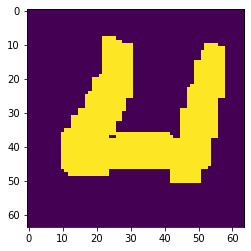

In [11]:
plt.imshow(X_test_all_masks[33] )

<function matplotlib.pyplot.show(close=None, block=None)>

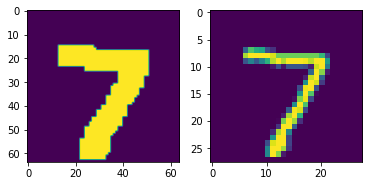

In [12]:
ind = 0
plt.subplot(121)
plt.imshow(X_test_all_masks[ind] )
plt.subplot(122)
plt.imshow(X_test_all[ind] )
plt.show

In [13]:
filename = 'C:/Users/ahmad/Desktop/JupyterFilesAUB/MNIST_Dataset/one_svm_MNIST_model_Dumm_class.sav'
OC_SVM_model = pickle.load(open(filename, 'rb'))

c:\ProgramData\anaconda3\envs\spd\lib\site-packages\sklearn\base.py:315: UserWarning: Trying to unpickle estimator OneClassSVM from version 1.3.0 when using version 0.24.2. This might lead to breaking code or invalid results. Use at your own risk.
  UserWarning)


In [14]:
X_adv_OCsvm = X_test_all_masks.reshape((len(X_test_all_masks), -1))
result = OC_SVM_model.predict(X_adv_OCsvm )
print((len(np.where(result==1)[0])/len(result)))

0.9915


In [15]:
print("Adversarail Detection Rate for eps = {} is \n".format(0.01),
      (len(np.where(result==-1)[0])/len(result)))

Adversarail Detection Rate for eps = 0.01 is 
 0.0085


In [14]:
# 5. Generate adversarial examples.
from attacks import maybe_generate_adv_examples
from utils.squeeze import reduce_precision_py
from utils.parameter_parser import parse_params
attack_string_hash = hashlib.sha1(FLAGS.attacks.encode('utf-8')).hexdigest()[:5]
sample_string_hash = task['test_set_selected_idx_hash'][:5]

from datasets_utils import get_next_class, get_least_likely_class
Y_test_target_next = get_next_class(Y_test)
Y_test_target_ll = get_least_likely_class(Y_pred)

X_test_adv_list = []
X_test_adv_discretized_list = []
Y_test_adv_discretized_pred_list = []

attack_string_list = filter(lambda x:len(x)>0, FLAGS.attacks.lower().split(';'))
to_csv = []

X_adv_cache_folder = os.path.join(FLAGS.result_folder, 'adv_examples')
adv_log_folder = os.path.join(FLAGS.result_folder, 'adv_logs')
predictions_folder = os.path.join(FLAGS.result_folder, 'predictions')
for folder in [X_adv_cache_folder, adv_log_folder, predictions_folder]:
    if not os.path.isdir(folder):
        os.makedirs(folder)

# predictions_fpath = os.path.join(predictions_folder, "legitimate.npy")
# np.save(predictions_fpath, Y_pred, allow_pickle=False)

In [15]:
if FLAGS.clip >= 0:
    epsilon = FLAGS.clip
    print ("Clip the adversarial perturbations by +-%f" % epsilon)
    max_clip = np.clip(X_test + epsilon, 0, 1)
    min_clip = np.clip(X_test - epsilon, 0, 1)

for attack_string in attack_string_list:
    attack_log_fpath = os.path.join(adv_log_folder, "%s_%s.log" % (task_id, attack_string.replace("?","_")))
    attack_name, attack_params = parse_params(attack_string)
    print ( "\nRunning attack: %s %s" % (attack_name, attack_params))

    if 'targeted' in attack_params:
        targeted = attack_params['targeted']
        print ("targeted value: %s" % targeted)
        if targeted == 'next':
            Y_test_target = Y_test_target_next
        elif targeted == 'll':
            Y_test_target = Y_test_target_ll
        elif targeted == False:
            attack_params['targeted'] = False
            Y_test_target = Y_test.copy()
    else:
        targeted = False
        attack_params['targeted'] = False
        Y_test_target = Y_test.copy()

    x_adv_fname = "%s_%s.pickle" % (task_id, attack_string.replace("?","_"))
    x_adv_fpath = os.path.join(X_adv_cache_folder, x_adv_fname)

    X_test_adv, aux_info = maybe_generate_adv_examples(sess, model, x, y, X_test, Y_test_target, attack_name, attack_params,
                                                        use_cache = x_adv_fpath, verbose=FLAGS.verbose, attack_log_fpath=attack_log_fpath)

    if FLAGS.clip > 0:
        # This is L-inf clipping.
        X_test_adv = np.clip(X_test_adv, min_clip, max_clip)

    X_test_adv_list.append(X_test_adv)

    if isinstance(aux_info, float):
        duration = aux_info
    else:
        duration = aux_info['duration']

    dur_per_sample = duration / len(X_test_adv)

    # 5.0 Output predictions.
    Y_test_adv_pred = model.predict(X_test_adv)
    predictions_fpath = os.path.join(predictions_folder, "%s.npy"% attack_string.replace("?","_"))
    np.save(predictions_fpath, Y_test_adv_pred, allow_pickle=False)

    # 5.1 Evaluate the adversarial examples being discretized to uint8.
    print ("\n---Attack (uint8): %s" % attack_string)
    # All data should be discretized to uint8.
    X_test_adv_discret = reduce_precision_py(X_test_adv, 256)
    X_test_adv_discretized_list.append(X_test_adv_discret)
    Y_test_adv_discret_pred = model.predict(X_test_adv_discret)
    Y_test_adv_discretized_pred_list.append(Y_test_adv_discret_pred)




Running attack: fgsm {'eps': 0.3}
Loading adversarial examples from [MNIST_100_2cd66_carlini_fgsm_eps=0.3.pickle].

---Attack (uint8): fgsm?eps=0.3

Running attack: bim {'eps': 0.3, 'eps_iter': 0.06}
Loading adversarial examples from [MNIST_100_2cd66_carlini_bim_eps=0.3&eps_iter=0.06.pickle].

---Attack (uint8): bim?eps=0.3&eps_iter=0.06

Running attack: carlinili {'targeted': 'next', 'batch_size': 1, 'max_iterations': 1000, 'confidence': 10.0}
targeted value: next
Loading adversarial examples from [MNIST_100_2cd66_carlini_carlinili_targeted=next&batch_size=1&max_iterations=1000&confidence=10.pickle].

---Attack (uint8): carlinili?targeted=next&batch_size=1&max_iterations=1000&confidence=10

Running attack: carlinili {'targeted': 'll', 'batch_size': 1, 'max_iterations': 1000, 'confidence': 10.0}
targeted value: ll
Loading adversarial examples from [MNIST_100_2cd66_carlini_carlinili_targeted=ll&batch_size=1&max_iterations=1000&confidence=10.pickle].

---Attack (uint8): carlinili?target

In [16]:
len(X_test_adv_discretized_list)

10

In [16]:
np.unique(X_test_adv_discretized_list[0][0])

array([0.        , 0.10980392, 0.11764706, 0.1254902 , 0.12941177,
       0.14117648, 0.23921569, 0.25882354, 0.27450982, 0.2901961 ,
       0.29803923, 0.34509805, 0.38431373, 0.41568628, 0.42352942,
       0.44705883, 0.4862745 , 0.49411765, 0.5019608 , 0.5411765 ,
       0.54901963, 0.5647059 , 0.6039216 , 0.68235296, 0.6901961 ,
       0.69803923, 0.72156864, 0.7294118 , 0.74509805, 0.8039216 ,
       0.8509804 , 0.8666667 , 0.9647059 , 0.98039216, 1.        ],
      dtype=float32)

In [17]:
dim = 64
attack_string_list = filter(lambda x:len(x)>0, FLAGS.attacks.lower().split(';'))
for i, attack_string in zip(range(len(X_test_adv_discretized_list)),attack_string_list):
    print(i)
    attack_name, attack_params = parse_params(attack_string)
    print ( "\tRunning attack: %s %s " % (attack_name, attack_params))
    x_adv_test_1 = np.array(X_test_adv_discretized_list[i])
    x_adv_test_1_ = []
    for img in x_adv_test_1:
        image = cv2.resize(img, (dim, dim)) 
        image = np.expand_dims(image, axis=2)
        x_adv_test_1_.append(image)
    x_adv_test_1 = np.array(x_adv_test_1_)
    X_test_adv_mask           = U_Net_Model.predict(x_adv_test_1,verbose=0)
    X_test_adv_preds_mask_t   = (X_test_adv_mask > 0.5).astype(np.uint8)
    X_test_adv_masks          = np.array( X_test_adv_preds_mask_t)
    X_adv_OCsvm = X_test_adv_masks.reshape((len(X_test_adv_masks), -1))
    result = OC_SVM_model.predict(X_adv_OCsvm )
    print("Adversarail Detection Rate for %s %s Attack   is \n"   % (attack_name, list(attack_params)[0]),
        str((len(np.where(result==-1)[0])/len(result))).center(50) )

0
	Running attack: fgsm {'eps': 0.3} 
Adversarail Detection Rate for fgsm eps Attack   is 
                        1.0                        
1
	Running attack: bim {'eps': 0.3, 'eps_iter': 0.06} 
Adversarail Detection Rate for bim eps Attack   is 
                        1.0                        
2
	Running attack: carlinili {'targeted': 'next', 'batch_size': 1, 'max_iterations': 1000, 'confidence': 10.0} 
Adversarail Detection Rate for carlinili targeted Attack   is 
                        1.0                        
3
	Running attack: carlinili {'targeted': 'll', 'batch_size': 1, 'max_iterations': 1000, 'confidence': 10.0} 
Adversarail Detection Rate for carlinili targeted Attack   is 
                        1.0                        
4
	Running attack: carlinil2 {'targeted': 'next', 'batch_size': 100, 'max_iterations': 1000, 'confidence': 10.0} 
Adversarail Detection Rate for carlinil2 targeted Attack   is 
                        1.0                        
5
	Running attack

In [47]:
attack_indx = 9
x_adv_test_1 = np.array(X_test_adv_discretized_list[attack_indx])
Y_pred_adv_test_1 = model.predict(x_adv_test_1)
Y_pred_adv_test_1 = np.argmax(Y_pred_adv_test_1,axis=1)
print("x_adv_test_1 shape".center(50) ,  x_adv_test_1.shape)
x_adv_test_1_ = []
for img in x_adv_test_1:
    image = cv2.resize(img, (dim, dim)) 
    image = np.expand_dims(image, axis=2)
    x_adv_test_1_.append(image)
x_adv_test_1 = np.array(x_adv_test_1_)
print("x_adv_test_1 shape".center(50) ,  x_adv_test_1.shape)

                x_adv_test_1 shape                 (100, 28, 28, 1)
                x_adv_test_1 shape                 (100, 64, 64, 1)


In [48]:
# from scipy import ndimage
# kernel = np.array([[0,1,0],
#                    [1,1,1],
#                    [0,1,0]],np.uint8)
# for i in range(len(x_adv_test_1)):
#     x_adv_test_1[i] = ndimage.median_filter(x_adv_test_1[i], size=3)
X_test_adv_mask           = U_Net_Model.predict(x_adv_test_1,verbose=0)
X_test_adv_preds_mask_t   = (X_test_adv_mask > 0.5).astype(np.uint8)
X_test_adv_masks          = np.array( X_test_adv_preds_mask_t)
adv_intersect_mask        = X_test_adv_masks * x_adv_test_1

<function matplotlib.pyplot.show(*, block=None)>

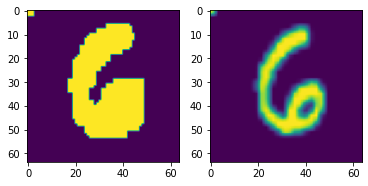

In [49]:
ind = 66
plt.subplot(121)
plt.imshow(X_test_adv_masks[ind] )
plt.subplot(122)
plt.imshow(x_adv_test_1[ind] )
plt.show

In [50]:
X_adv_OCsvm = X_test_adv_masks.reshape((len(X_test_adv_masks), -1))
result = OC_SVM_model.predict(X_adv_OCsvm )
print((len(np.where(result==1)[0])/len(result)))
print("Adversarail Detection Rate for eps = {} is \n".format(0.01),
      (len(np.where(result==-1)[0])/len(result)))

0.98
Adversarail Detection Rate for eps = 0.01 is 
 0.02


In [51]:
adversarail_check = np.where(result==1)[0]
adv_labels        = np.copy(Y_pred_adv_test_1)
len(adversarail_check)


98

In [52]:
adv_labels

array([3, 3, 5, 6, 3, 2, 6, 0, 8, 6, 3, 3, 2, 3, 3, 0, 6, 7, 8, 8, 0, 3,
       9, 8, 3, 5, 6, 6, 8, 8, 0, 8, 9, 0, 3, 2, 6, 7, 8, 6, 3, 3, 2, 3,
       4, 5, 6, 6, 8, 6, 3, 3, 2, 6, 4, 2, 6, 8, 8, 9, 3, 3, 5, 3, 4, 2,
       6, 7, 7, 1, 0, 3, 2, 3, 3, 5, 6, 8, 8, 6, 0, 3, 5, 0, 4, 5, 6, 6,
       8, 6, 0, 3, 6, 3, 4, 5, 6, 8, 8, 6], dtype=int64)

In [53]:
adversarail_check.shape

(98,)

In [65]:
adv_cls = 10
for i in range(len(adv_labels)):
    if i in adversarail_check:
        adv_labels[i] = adv_labels[i]
    else:
        print(i)
        adv_labels[i] = adv_cls

46
54


In [66]:
adv_labels

array([ 3,  3,  5,  6,  3,  2,  6,  0,  8,  6,  3,  3,  2,  3,  3,  0,  6,
        7,  8,  8,  0,  3,  9,  8,  3,  5,  6,  6,  8,  8,  0,  8,  9,  0,
        3,  2,  6,  7,  8,  6,  3,  3,  2,  3,  4,  5, 10,  6,  8,  6,  3,
        3,  2,  6, 10,  2,  6,  8,  8,  9,  3,  3,  5,  3,  4,  2,  6,  7,
        7,  1,  0,  3,  2,  3,  3,  5,  6,  8,  8,  6,  0,  3,  5,  0,  4,
        5,  6,  6,  8,  6,  0,  3,  6,  3,  4,  5,  6,  8,  8,  6],
      dtype=int64)

In [56]:
from Util_MNIST import local_K_means_seg_new
classes                       = np.array([0,1,2, 3,4,5,6, 7,8,9,10])
clusters                      = np.array([6,3,5,11,6,6,3,11,3,3,4 ])
# clusters                    = np.array             ([3,11,3,3,6,3,3,5,4,4])# extracted Before
segmented_imgs, inverted_imgs = local_K_means_seg_new(np.copy(adv_intersect_mask), clusters, np.copy(adv_labels))
len(segmented_imgs)

100

In [67]:
Y_GroudTruth      = np.argmax(Y_test_all,axis=1)
Y_test_GroudTruth = Y_GroudTruth[selected_idx]
# Y_test_GroudTruth
print(len(Y_test_GroudTruth))
adversarail_samples = np.where(Y_test_GroudTruth!=adv_labels)[0]
print(len(adversarail_samples))

def detect(segmented_imgs,inverted_imgs,adv_labels,adversarail_samples,adv_cls):
    adv_final_seg_pred  = MNIST_Seg_model.predict(segmented_imgs,verbose=0)
    adv_final_inv_pred  = MNIST_Seg_model.predict(inverted_imgs, verbose=0)
    adv_final_seg_Cls   = np.argmax(adv_final_seg_pred, axis=1)
    adv_final_inv_Cls   = np.argmax(adv_final_inv_pred, axis=1)

    adv_final_seg_Cls_   = adv_final_seg_Cls [adversarail_samples]
    adv_final_inv_Cls_   = adv_final_inv_Cls [adversarail_samples]
    adv_labels_          = adv_labels        [adversarail_samples]
    adv_final_seg_pred_  = adv_final_seg_pred[adversarail_samples]
    adv_final_inv_pred_  = adv_final_inv_pred[adversarail_samples]
    indeces_eq          = np.where(adv_final_seg_Cls_==adv_final_inv_Cls_)[0]

    pred_inv_plus_seg = []
    for i in range(len(adv_labels_)):
        if i in indeces_eq:
            if(adv_labels_[i]==adv_cls):
                #Detected_Attack
                pred_inv_plus_seg.append(+1)
            elif(adv_final_seg_Cls_[i]==adv_cls):
                #Detected_Attack
                pred_inv_plus_seg.append(+1)
            elif adv_labels_[i] == adv_final_seg_Cls_[i]:
                #successful_Attack , Benign_sample
                pred_inv_plus_seg.append(-1)
            else:
                #Detected_Attack
                pred_inv_plus_seg.append(+1)
        else:
            #already two different prediction Detected Attack
            pred_inv_plus_seg.append(+1)
    print(len(pred_inv_plus_seg))
    pred_inv_plus_seg   = np.array(pred_inv_plus_seg)
    detected_examples   = len(np.where(pred_inv_plus_seg==+1)[0])
    successful_examples = len(np.where(pred_inv_plus_seg==-1)[0])
    print("Detection Rate                                         {:.2f}% ".format(detected_examples/pred_inv_plus_seg.shape[0]*100))
    print("Successful Rate                                        {:.2f}% ".format(successful_examples/pred_inv_plus_seg.shape[0]*100))
    print("Successful Examples                                   ",successful_examples ,"out of", 
        pred_inv_plus_seg.shape[0])

    # print("Recovery Rate using only the segmented                 ",
    #       len(np.where(np.array(adv_final_seg_Cls)==np.array(Y_test_GroudTruth))[0])/np.array(adv_final_seg_Cls).shape[0]*100)
    # print("Adversarial Successful Rate using only the segmented   ",
    #       len(np.where(np.array(adv_final_seg_Cls)==np.array(adv_labels_))[0])/np.array(adv_final_seg_Cls).shape[0]*100)
    # successful_attacks_seg = len(np.where(np.array(adv_final_seg_Cls)==np.array(adv_labels_))[0]) 
    # print("Successful Adversarial Examples using only the segmented",successful_attacks_seg)
    # print("Detection Rate using only the segmented images         ",
    #       ((np.array(adv_final_seg_Cls).shape[0] - successful_attacks_seg)
    #         /np.array(adv_final_seg_Cls).shape[0]*100))
    # else:
    #     print("Detection Rate                                        {}% ".format(100))
    return np.where(pred_inv_plus_seg==-1)[0] , adv_final_seg_Cls_, adv_final_inv_Cls_,adv_final_seg_pred_,adv_final_inv_pred_
successfull_indx , seg_cls,inv_cls,seg_pred,inv_pred = detect(np.copy(segmented_imgs),np.copy(inverted_imgs),np.copy(adv_labels),np.copy(adversarail_samples),adv_cls)

100
55
55
Detection Rate                                         94.55% 
Successful Rate                                        5.45% 
Successful Examples                                    3 out of 55


In [70]:
len(adversarail_samples)

55

In [68]:
successfull_indx

array([ 1, 40, 46], dtype=int64)

In [62]:
segmented_imgs_ = segmented_imgs   [adversarail_samples]
inverted_imgs_  = inverted_imgs    [adversarail_samples]
adv_labels__    = adv_labels       [adversarail_samples]
x_adv_test_2    = x_adv_test_1     [adversarail_samples]
Y_test_Groud    = Y_test_GroudTruth[adversarail_samples]

<function matplotlib.pyplot.show(*, block=None)>

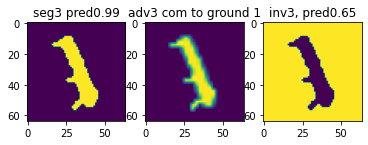

In [64]:
ind = 46
plt.subplot(131)
plt.imshow(segmented_imgs_[ind] )
plt.title("seg{} pred{:.2f}".format(seg_cls[ind],np.max(seg_pred[ind])))
plt.subplot(132)
plt.imshow(x_adv_test_2[ind] )
plt.title("adv{} com to ground {}".format(adv_labels__[ind],Y_test_Groud[ind]))
plt.subplot(133)
plt.imshow(inverted_imgs_[ind] )
plt.title("inv{}, pred{:.2f}".format(inv_cls[ind],np.max(inv_pred[ind])))

plt.show

In [41]:
Y_GroudTruth = np.argmax(Y_test_all,axis=1)
Y_test_GroudTruth = Y_GroudTruth[selected_idx]
Y_test_GroudTruth
print(len(Y_test_GroudTruth[adversarail_check]))
adversarail_samples = np.where(Y_test_GroudTruth[adversarail_check]!=adv_labels[adversarail_check])[0]
print(len(adversarail_samples))
adv_final_seg_pred  = MNIST_Seg_model.predict(segmented_imgs,verbose=0)
adv_final_inv_pred  = MNIST_Seg_model.predict(inverted_imgs, verbose=0)
adv_final_seg_Cls   = np.argmax(adv_final_seg_pred, axis=1)
adv_final_inv_Cls   = np.argmax(adv_final_inv_pred, axis=1)

adv_final_seg_Cls   = adv_final_seg_Cls[adversarail_samples]
adv_final_inv_Cls   = adv_final_inv_Cls[adversarail_samples]
adv_labels_         = adv_labels       [adversarail_samples]
indeces_eq          = np.where(adv_final_seg_Cls==adv_final_inv_Cls)[0]

pred_inv_plus_seg = []
for i in range(len(adv_labels_)):
  if i in indeces_eq:
    #check original with one of the two prediction arrays let's choose inverted
    if adv_labels_[i] == adv_final_seg_Cls[i]:
      #successful_Attack , Benign_sample
      pred_inv_plus_seg.append(-1)
    else:
      #Detected_Attack
      pred_inv_plus_seg.append(+1)
  else:
    #already two different prediction Detected Attack
    pred_inv_plus_seg.append(+1)
pred_inv_plus_seg   = np.array(pred_inv_plus_seg)
detected_examples   = len(np.where(pred_inv_plus_seg==1)[0])
successful_examples = len(np.where(pred_inv_plus_seg==-1)[0])
print("Detection Rate                                         ",detected_examples/pred_inv_plus_seg.shape[0]*100)
print("Successful Rate                                        ",successful_examples/pred_inv_plus_seg.shape[0]*100)
print("Successful Examples                                    ",successful_examples ,"out of", 
      pred_inv_plus_seg.shape[0])

# print("Recovery Rate using only the segmented                 ",
#       len(np.where(np.array(adv_final_seg_Cls)==np.array(Y_test_GroudTruth))[0])/np.array(adv_final_seg_Cls).shape[0]*100)
# print("Adversarial Successful Rate using only the segmented   ",
#       len(np.where(np.array(adv_final_seg_Cls)==np.array(adv_labels_))[0])/np.array(adv_final_seg_Cls).shape[0]*100)
# successful_attacks_seg = len(np.where(np.array(adv_final_seg_Cls)==np.array(adv_labels_))[0]) 
# print("Successful Adversarial Examples using only the segmented",successful_attacks_seg)
# print("Detection Rate using only the segmented images         ",
#       ((np.array(adv_final_seg_Cls).shape[0] - successful_attacks_seg)
#         /np.array(adv_final_seg_Cls).shape[0]*100))

93
93
Detection Rate                                          83.87096774193549
Successful Rate                                         16.129032258064516
Successful Examples                                     15 out of 93


In [38]:
np.where(pred_inv_plus_seg==-1)[0]

array([ 2, 11, 13, 22, 25, 29, 52, 59, 83], dtype=int64)

In [39]:
ind = 2
plt.subplot(121)
plt.imshow(segmented_imgs[ind] )
plt.title(adv_final_seg_Cls[ind])
plt.subplot(122)
plt.imshow(x_adv_test_1[ind] )
plt.title("adv{} com to grount {}".format(adv_labels_[ind],Y_test_GroudTruth[ind]))
plt.show

c:\ProgramData\anaconda3\envs\spd\lib\site-packages\ipykernel_launcher.py:2: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  
c:\ProgramData\anaconda3\envs\spd\lib\site-packages\ipykernel_launcher.py:5: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  """


<function matplotlib.pyplot.show(*, block=None)>

In [84]:
# np.where(np.argmax(Y_test_all[selected_idx],axis=1)==adv_labels_)[0]